# Xray Lung Classifier

---
### Project flow  

1) Importing the libraries and Loading the Images

2) Exploring the Images and transforming the Images

3) Creating the model Architecture

4) Training the Data

5) Evaluate the Model

In [ ]:
!pip install grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

In [ ]:
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
%matplotlib inline
from PIL import Image
from IPython.display import display
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.optim.lr_scheduler import StepLR, ReduceLROnPlateau
from torchsummary import summary
from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
precision_score,
recall_score,
confusion_matrix,
classification_report,
f1_score
)

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Path to dataset files: /kaggle/input/chest-xray-pneumonia


In [ ]:
files = os.listdir(path)
print(files)

['chest_xray']


In [ ]:
data_path = path + '/chest_xray'

data_files = os.listdir(data_path)
print(data_files)

['chest_xray', '__MACOSX', 'val', 'test', 'train']


In [ ]:
len(os.listdir(data_path+'/train/PNEUMONIA'))

3875

In [ ]:
# Defining the class name
class_name = ['NORMAL','PNEUMONIA']

# Creating a function to  get the list of files
def get_list_of_files(dir_name):
    '''
    input - The input directory location
    output - Returns the list the files in the directory
    '''
    files_list = os.listdir(dir_name)
    return files_list
train_normal_file = get_list_of_files(data_path+'/train/'+class_name[0])
train_pneumonia_file = get_list_of_files(data_path+'/train/'+class_name[1])
test_normal_file = get_list_of_files(data_path+'/test/'+class_name[0])
test_pneumonia_file = get_list_of_files(data_path+'/test/'+class_name[1])
val_normal_file = get_list_of_files(data_path+'/val/'+class_name[0])
val_pneumonia_file = get_list_of_files(data_path+'/val/'+class_name[1])



In [ ]:
print("Number of train samples in Normal category {}".format(len(train_normal_file)))
print("Number of train samples in Pneumonia category {}".format(len(train_pneumonia_file)))

print("Number of validation samples in Normal category {}".format(len(val_normal_file)))
print("Number of validation samples in Pneumonia category {}".format(len(val_pneumonia_file)))

print("Number of test samples in Normal category {}".format(len(test_normal_file)))
print("Number of test samples in Pneumonia category {}".format(len(test_pneumonia_file)))

Number of train samples in Normal category 1341
Number of train samples in Pneumonia category 3875
Number of validation samples in Normal category 8
Number of validation samples in Pneumonia category 8
Number of test samples in Normal category 234
Number of test samples in Pneumonia category 390


In [ ]:
data_path

'/kaggle/input/chest-xray-pneumonia/chest_xray'

(1426, 1584)


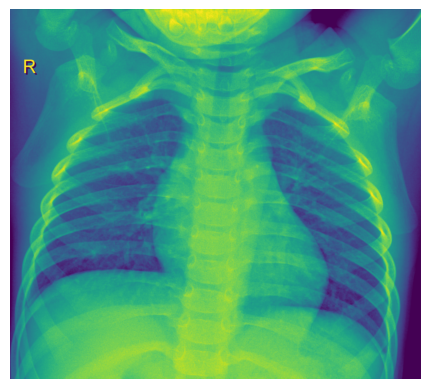

In [ ]:
#  Let's print the Normal and Pneumonia images from Training folder

rand_img_no = np.random.randint(0,len(train_normal_file))
img = data_path + '/train/NORMAL/'+ train_normal_file[rand_img_no]
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)

plt.axis('off')
plt.show()

(1029, 1446)


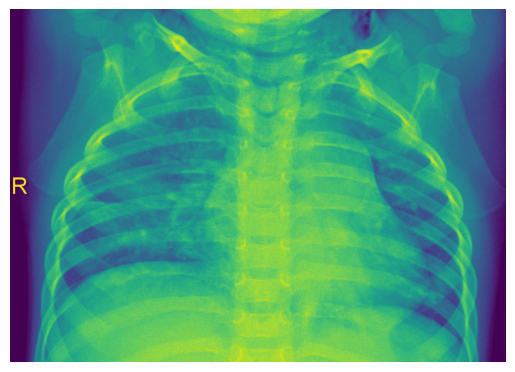

In [ ]:
#  Let's print the Normal and Pneumonia images from Training folder

rand_img_no = np.random.randint(0,len(train_pneumonia_file))
img = data_path + '/train/PNEUMONIA/'+ train_pneumonia_file[rand_img_no]
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)

plt.axis('off')
plt.show()

#### same doing for test images

(2071, 2022)


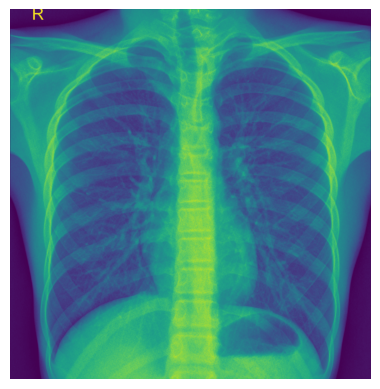

In [ ]:

rand_img_no = np.random.randint(0,len(test_normal_file))
img = data_path + '/test/NORMAL/'+ test_normal_file[rand_img_no]
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)

plt.axis('off')
plt.show()

Image for pneumonia
(768, 1168)


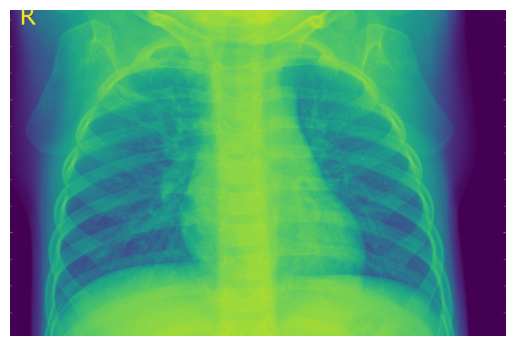

In [ ]:
rand_img_no = np.random.randint(0,len(test_pneumonia_file))
img = data_path + '/test/PNEUMONIA/'+ test_pneumonia_file[rand_img_no]
print("Image for pneumonia")
print(plt.imread(img).shape)
img = mpimg.imread(img)
imgplot = plt.imshow(img)

plt.axis('off')
plt.show()

### Transforming the Images

- Now that we have seen the sample of the images let's transform the data now
- We need to perform transformation on both train and test images
- For Training data we need to perform the data augmentation also.
- Data Augmentation is done to create synthetic data.

In **Transformation** we are doing Resize,CenterCrop,ColorJitter,RandomHorizontalFlip,RandomRotation,ToTensor and Normalize.

- Resize:- Resize the input image to the given size.
- CenterCrop:- Crops the given image at the center.
- ColorJitter:- Randomly change the brightness, contrast, saturation and hue of an image.
- RandomHorizontalFlip:- Horizontally flip the given image randomly with a given probability.
- RandomRotation:- Rotate the image by angle.
- ToTensor:- Convert numpy.ndarray to tensor.
- Normalize:- Normalize a float tensor image with mean and standard deviation.

--------------------
#### **Why no ColorJitter or Rotation in test_transform?**
 We want the test (or validation) images to be as clean and consistent as possible. You should only apply "Data Augmentation" (random changes) to the training data to teach the model to be flexible; you should never augment the test data because you want to evaluate the model on the "real" image.

#### **Why those specific numbers in Normalize?**
These are the exact mean and standard deviation values calculated from the ImageNet dataset. If you are using a pre-trained model (like ResNet or VGG), your inputs must be normalized this way, or the model will not perform accurately.

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize(224),                # Resizes the smaller edge of the image to 224 pixels while maintaining aspect ratio
    transforms.CenterCrop(224),            # Crops the center of the image to a 224x224 square

     # Augmentation too
    transforms.ColorJitter(brightness=0.10, contrast=0.1, saturation=0.20, hue=0.15), # Randomly changes image colors to improve model robustness
    transforms.RandomHorizontalFlip(),     # Randomly flips the image horizontally (50% probability)
    transforms.RandomRotation(10),         # Randomly rotates the image by a degree between -10 and +10


    transforms.ToTensor(),                 # Converts the image from PIL/numpy format to a PyTorch Tensor and scales pixel values from [0, 255] to [0.0, 1.0]
    transforms.Normalize([0.485, 0.456, 0.406], # Normalizes the image using ImageNet mean statistics for RGB channels
                          [0.229, 0.224, 0.225]) # Normalizes the image using ImageNet standard deviation statistics
])

test_transform = transforms.Compose([
    transforms.Resize(224),                # Resizes image to 224 pixels
    transforms.CenterCrop(224),            # Crops center to 224x224
    transforms.ToTensor(),                 # Converts to Tensor (pixel values [0.0, 1.0])
    transforms.Normalize([0.485, 0.456, 0.406], # Applies same ImageNet normalization as training
                          [0.229, 0.224, 0.225])
])

### Creating Data Loader

- For our usecase will be using the default data loader for Pytorch.
- We will be creating 2 data loaders one for the training data and other for the test data.
- batch size is a hyperparameter which we can tweak according to our need and system configuration.
- We can provide Image shuffling True for training data and False for test data.
- Pin memory is used to transfer the loaded dataset from CPU to GPU.

In [ ]:
data_path

'/kaggle/input/chest-xray-pneumonia/chest_xray'

In [ ]:
train_data = datasets.ImageFolder(os.path.join(data_path, 'train'), transform= train_transform)
test_data = datasets.ImageFolder(os.path.join(data_path, 'test'), transform= test_transform)

val_transform = test_transform # Use the same clean transform as your test set
val_data = datasets.ImageFolder(os.path.join(data_path, 'val'), transform=val_transform)


train_loader = DataLoader(train_data,
                          batch_size= 2, shuffle= True, pin_memory= True)

test_loader = DataLoader(test_data,
                         batch_size= 2, shuffle= False, pin_memory= True)

val_loader = DataLoader(val_data,
                        batch_size=2, shuffle=False, pin_memory=True)
class_names = train_data.classes
print(class_names)
print(f'Number of train images: {len(train_data)}')
print(f'Number of test images: {len(test_data)}')
print(f'Number of validation images: {len(val_data)}')

['NORMAL', 'PNEUMONIA']
Number of train images: 5216
Number of test images: 624
Number of validation images: 16


---
### Creating the model Architecture

- First Layer is the **input layer** consisting of 3 input channels and output channels with kernel_size of 3X3, padding=0 and bias=True. The activation function we are using is ReLU and performing batch normalization.
- Then we are performing max pooling to extract the important features out of the image.
- Similarly we are passing our model through 9 convolutional layers.
- Finally we are passing out passing our model through a output layer in which we are getting binary classification.


In [ ]:

class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResBlock, self).__init__()
        # The "Residual" path
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, stride=stride, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1, stride=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # Shortcut to match dimensions if in != out
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        residual = self.shortcut(x)
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out += residual # The magic of ResNet
        return F.relu(out)

class RobustXrayNet(nn.Module):
    def __init__(self):
        super(RobustXrayNet, self).__init__()
        # Initial expansion
        self.conv_in = nn.Sequential(nn.Conv2d(3, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU())

        # ResNet-style blocks (Scaling channels)
        self.layer1 = ResBlock(32, 64, stride=2)
        self.layer2 = ResBlock(64, 128, stride=2)
        self.layer3 = ResBlock(128, 256, stride=2)

        # Classifier Head
        self.gap = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(256, 2)
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        x = self.conv_in(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.gap(x)
        x = x.flatten(1)
        x = self.dropout(x)
        return self.fc(x)

In [ ]:
# Create a dummy image (Batch size 1, 3 channels, 224x224)
dummy_input = torch.randn(1, 3, 360, 360)
model = RobustXrayNet()

# Run it through the model
output = model(dummy_input)

# Check the final output shape
print(f"Output shape: {output.shape}") # Should be torch.Size([1, 2])

Output shape: torch.Size([1, 2])


In [ ]:
# To check weather cuda is available in the system or not
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
print("Available processor {}".format(device))
model = RobustXrayNet().to(device)
# To check the model summary
summary(model, input_size=(3, 360, 360))

Available processor cuda
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 360, 360]             896
       BatchNorm2d-2         [-1, 32, 360, 360]              64
              ReLU-3         [-1, 32, 360, 360]               0
            Conv2d-4         [-1, 64, 180, 180]           2,048
       BatchNorm2d-5         [-1, 64, 180, 180]             128
            Conv2d-6         [-1, 64, 180, 180]          18,432
       BatchNorm2d-7         [-1, 64, 180, 180]             128
            Conv2d-8         [-1, 64, 180, 180]          36,864
       BatchNorm2d-9         [-1, 64, 180, 180]             128
         ResBlock-10         [-1, 64, 180, 180]               0
           Conv2d-11          [-1, 128, 90, 90]           8,192
      BatchNorm2d-12          [-1, 128, 90, 90]             256
           Conv2d-13          [-1, 128, 90, 90]          73,728
      BatchNor

### training the data

In [ ]:
train_losses = []
test_losses = []
train_acc = []
test_acc = []

 # Weights: [Normal_Weight, Pneumonia_Weight]
 # We give Normal class a higher weight (3.0) because there are fewer of them
weights = torch.tensor([3.0, 1.0]).to(device)
criterion = nn.CrossEntropyLoss(weight=weights, label_smoothing=0.1)

def train(model, device, train_loader, optimizer, epoch):
    """
    Description: To train the model

    input: model,device,train_loader,optimizer,epoch

    output: loss, batch id and accuracy
    """
    model.train()
    pbar = tqdm(train_loader)
    correct = 0
    processed = 0

    for batch_idx, (data, target) in enumerate(pbar):

        data, target = data.to(device), target.to(device)

      # Initialization of gradient
        optimizer.zero_grad()
        # In PyTorch, gradient is accumulated over backprop and even though thats used in RNN generally not used in CNN
        # or specific requirements
        ## prediction on data
        y_pred = model(data)


        # Calculating loss given the prediction
        loss = criterion(y_pred, target)

        # Save loss as a float, NOT a tensor
        train_losses.append(loss.item())

        # backward
        loss.backward()
        optimizer.step()

        # Accuracy tracking
        pred = y_pred.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
        correct += pred.eq(target.view_as(pred)).sum().item() # 1 or 0
        processed += len(data)

        pbar.set_description(desc= f'Loss={loss.item()} Batch_id={batch_idx} Accuracy={100*correct/processed:0.2f}')
        train_acc.append(100*correct/processed)

def test(model, device, test_loader):
    """
    Description: To test the model

    input: model,device,test_loader

    output: loss, batch id and accuracy
    """
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)

            test_loss += criterion(output, target).item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader) # Divide by number of batches
    test_losses.append(test_loss)
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
            test_loss, correct, len(test_loader.dataset),
            100. * correct / len(test_loader.dataset)))

    test_acc.append(100. * correct / len(test_loader.dataset))



In [ ]:
# Defining the params for training
model =  RobustXrayNet().to(device)

# AdamW is better than Adam because it handles weight decay much better,
#optimizer = torch.optim.AdamW(model.parameters(), lr=0.001, weight_decay=1e-4)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),lr=0.0001)

scheduler = StepLR(optimizer, step_size=5, gamma=0.75)
# Instead of StepLR
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='max', factor=0.5, patience=2, verbose=True
# )

EPOCHS =  15
# Training the model
for epoch in range(EPOCHS):
    print("EPOCH:", epoch + 1)
    train(model, device, train_loader, optimizer, epoch)
    scheduler.step()
    print('current Learning Rate: ', optimizer.state_dict()["param_groups"][0]["lr"])
    test(model, device, test_loader)

EPOCH: 1


Loss=0.4500765800476074 Batch_id=2607 Accuracy=84.99: 100%|██████████| 2608/2608 [03:03<00:00, 14.23it/s]


current Learning Rate:  0.0001

Test set: Average loss: 0.6328, Accuracy: 508/624 (81.41%)

EPOCH: 2


Loss=0.44158709049224854 Batch_id=2607 Accuracy=90.62: 100%|██████████| 2608/2608 [02:40<00:00, 16.26it/s]


current Learning Rate:  0.0001

Test set: Average loss: 0.6767, Accuracy: 497/624 (79.65%)

EPOCH: 3


...

current Learning Rate:  5.6250000000000005e-05

Test set: Average loss: 0.5410, Accuracy: 538/624 (86.22%)

EPOCH: 14


Loss=0.45595040917396545 Batch_id=2607 Accuracy=95.49: 100%|██████████| 2608/2608 [02:39<00:00, 16.35it/s]


current Learning Rate:  5.6250000000000005e-05

Test set: Average loss: 0.5412, Accuracy: 544/624 (87.18%)

EPOCH: 15


Loss=0.4873325824737549 Batch_id=2607 Accuracy=95.63: 100%|██████████| 2608/2608 [02:38<00:00, 16.42it/s]


current Learning Rate:  4.21875e-05

Test set: Average loss: 0.5790, Accuracy: 525/624 (84.13%)



In [ ]:
# After training completes
torch.save(model, 'XRay_model-v1.pt')

In [ ]:
import bentoml

# Ensure your model is on CPU before saving
model.to("cpu")
model.eval()

# Save YOUR custom model to the local store
saved_model = bentoml.pytorch.save_model(
    "XRay_model-v1",      # Give it a custom name
    model,                  # Your custom trained model
    signatures={            
        "__call__": {
            "batchable": True, 
            "batch_dim": 0
        }
    }
)

print(f"Model saved successfully: {saved_model}")

In [ ]:


print(f'Number of validation images: {len(val_data)}')

def validate(model, device, val_loader):
    model.eval()
    val_loss = 0
    correct = 0

    # We don't need gradients for validation
    with torch.no_grad():
        for data, target in val_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)

            # Using CrossEntropyLoss (same as training)
            val_loss += criterion(output, target).item()

            # Accuracy tracking
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(target.view_as(pred)).sum().item()

    val_loss /= len(val_loader.dataset)
    accuracy = 100. * correct / len(val_loader.dataset)

    print(f'\nValidation set: Average loss: {val_loss:.4f}, '
          f'Accuracy: {correct}/{len(val_loader.dataset)} ({accuracy:.2f}%)\n')

    return accuracy

Number of validation images: 16


In [ ]:
# If you are using your loaded model
val_acc = validate(model, device, val_loader)


Validation set: Average loss: 0.4203, Accuracy: 9/16 (56.25%)



In [ ]:
# If you are using your loaded model
validate(model, device, test_loader)


Validation set: Average loss: 0.2895, Accuracy: 525/624 (84.13%)



84.13461538461539

### Evaluate the Model

- Plotting the graph for taining loss and training accuracy
- Plotting the graph for test loss and test accuracy

Text(0.5, 1.0, 'Test Accuracy')

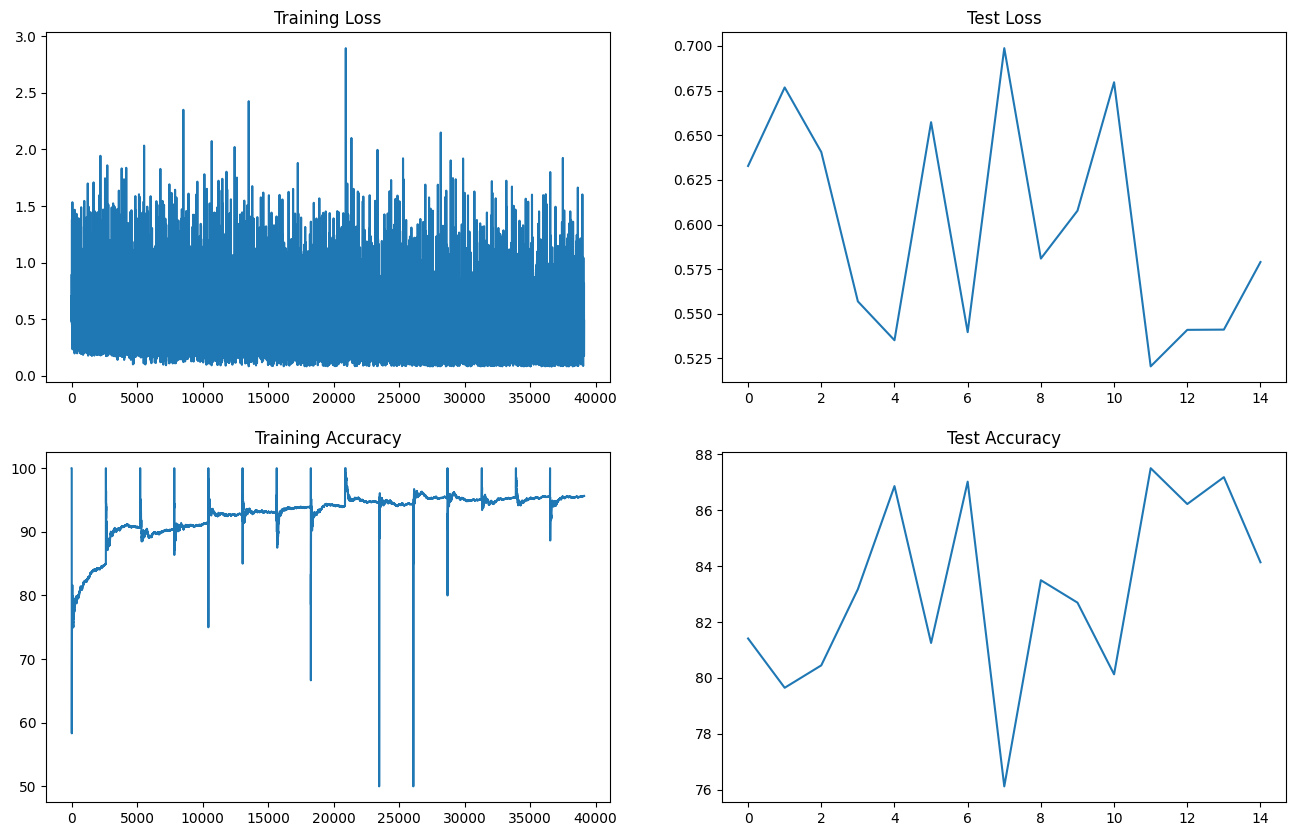

In [ ]:
train_losses1 = [i for i in train_losses]
train_acc1 = [i for i in train_acc]
test_losses1 = [i for i in test_losses]
test_acc1 = [i for i in test_acc]
fig, axs = plt.subplots(2,2,figsize=(16,10))
axs[0, 0].plot(train_losses1)
axs[0, 0].set_title("Training Loss")
axs[1, 0].plot(train_acc1)
axs[1, 0].set_title("Training Accuracy")
axs[0, 1].plot(test_losses1)
axs[0, 1].set_title("Test Loss")
axs[1, 1].plot(test_acc1)
axs[1, 1].set_title("Test Accuracy")


In [ ]:
def evaluate_model(model, device, test_loader):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)

            # Get predictions
            pred = output.argmax(dim=1, keepdim=True).squeeze()

            # Append to lists (move to CPU first!)
            all_preds.extend(pred.cpu().numpy())
            all_labels.extend(target.cpu().numpy())

    # Now calculate metrics
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1 Score: {f1:.4f}")
    print("="*40)
    print(f"Confusion Matrix: \n {confusion_matrix(all_labels, all_preds)}")
    print("="*40)
    print(f"Classification Report: \n {classification_report(all_labels, all_preds, target_names=['NORMAL', 'PNEUMONIA'])}")

# Call this function
evaluate_model(model, device, test_loader)

Precision: 0.8644
Recall: 0.8413
F1 Score: 0.8308
Confusion Matrix: 
 [[140  94]
 [  5 385]]
Classification Report: 
               precision    recall  f1-score   support

      NORMAL       0.97      0.60      0.74       234
   PNEUMONIA       0.80      0.99      0.89       390

    accuracy                           0.84       624
   macro avg       0.88      0.79      0.81       624
weighted avg       0.86      0.84      0.83       624



In [ ]:
import pickle

metrics_data = {
    'train_losses': train_losses,
    'test_losses': test_losses,
    'train_acc': train_acc,
    'test_acc': test_acc
}

with open('training_metrics.pkl', 'wb') as f:
    pickle.dump(metrics_data, f)

print("Training metrics saved to training_metrics.pkl")

Training metrics saved to training_metrics.pkl


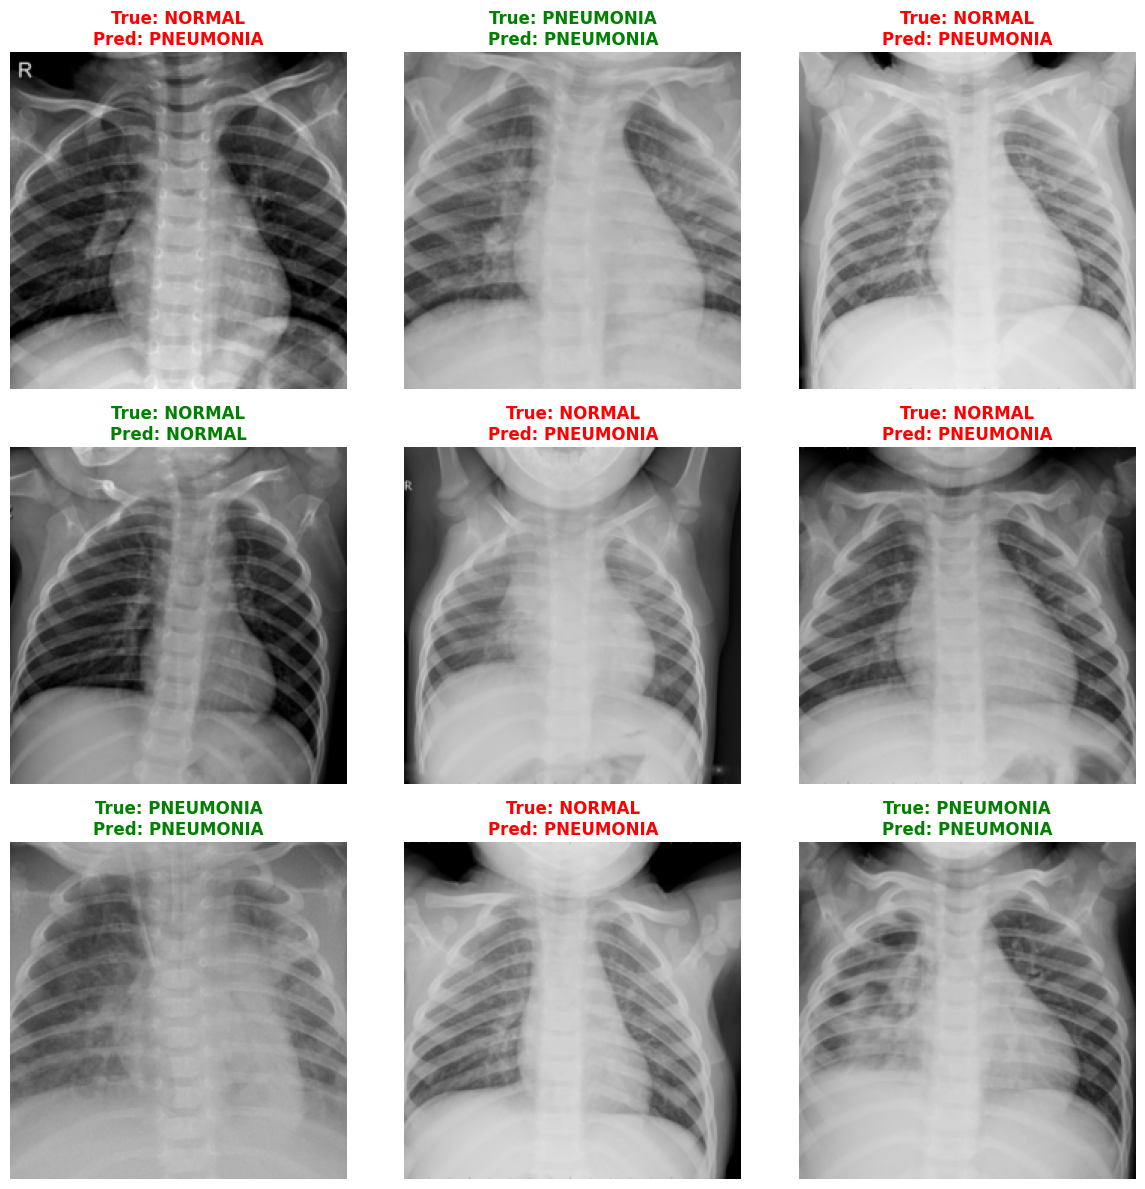

In [ ]:
# 1. Get a larger batch for visualization
# We need at least 9 images to fill 3x3 grid
temp_loader = DataLoader(val_data, batch_size=9, shuffle=True)
images, labels = next(iter(temp_loader))

images_gpu = images.to(device)

# 2. Get predictions using your model
model.eval()
with torch.no_grad():
    outputs = model(images_gpu)
    preds = torch.argmax(outputs, dim=1)

# Move back to CPU
images = images.cpu()
labels = labels.cpu()
preds = preds.cpu()

# 3. Setup normalization reversal
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])

class_names = ['NORMAL', 'PNEUMONIA'] # Matches your class order

# 4. Plotting
fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i, ax in enumerate(axes.flat):
    if i < len(images):

        # Denormalize
        img = images[i].permute(1, 2, 0).numpy()
        img = std * img + mean
        img = np.clip(img, 0, 1)

        true_label = class_names[labels[i]]
        pred_label = class_names[preds[i]]

        ax.imshow(img)
        # Color code: Green if correct, Red if wrong
        color = 'green' if true_label == pred_label else 'red'
        ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontweight='bold')
        ax.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
!pip install grad-cam
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 107.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=452e397f28c8f4b4b536f207da80649ff59dcd6821d0c077ce8c4cecc7eea859
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


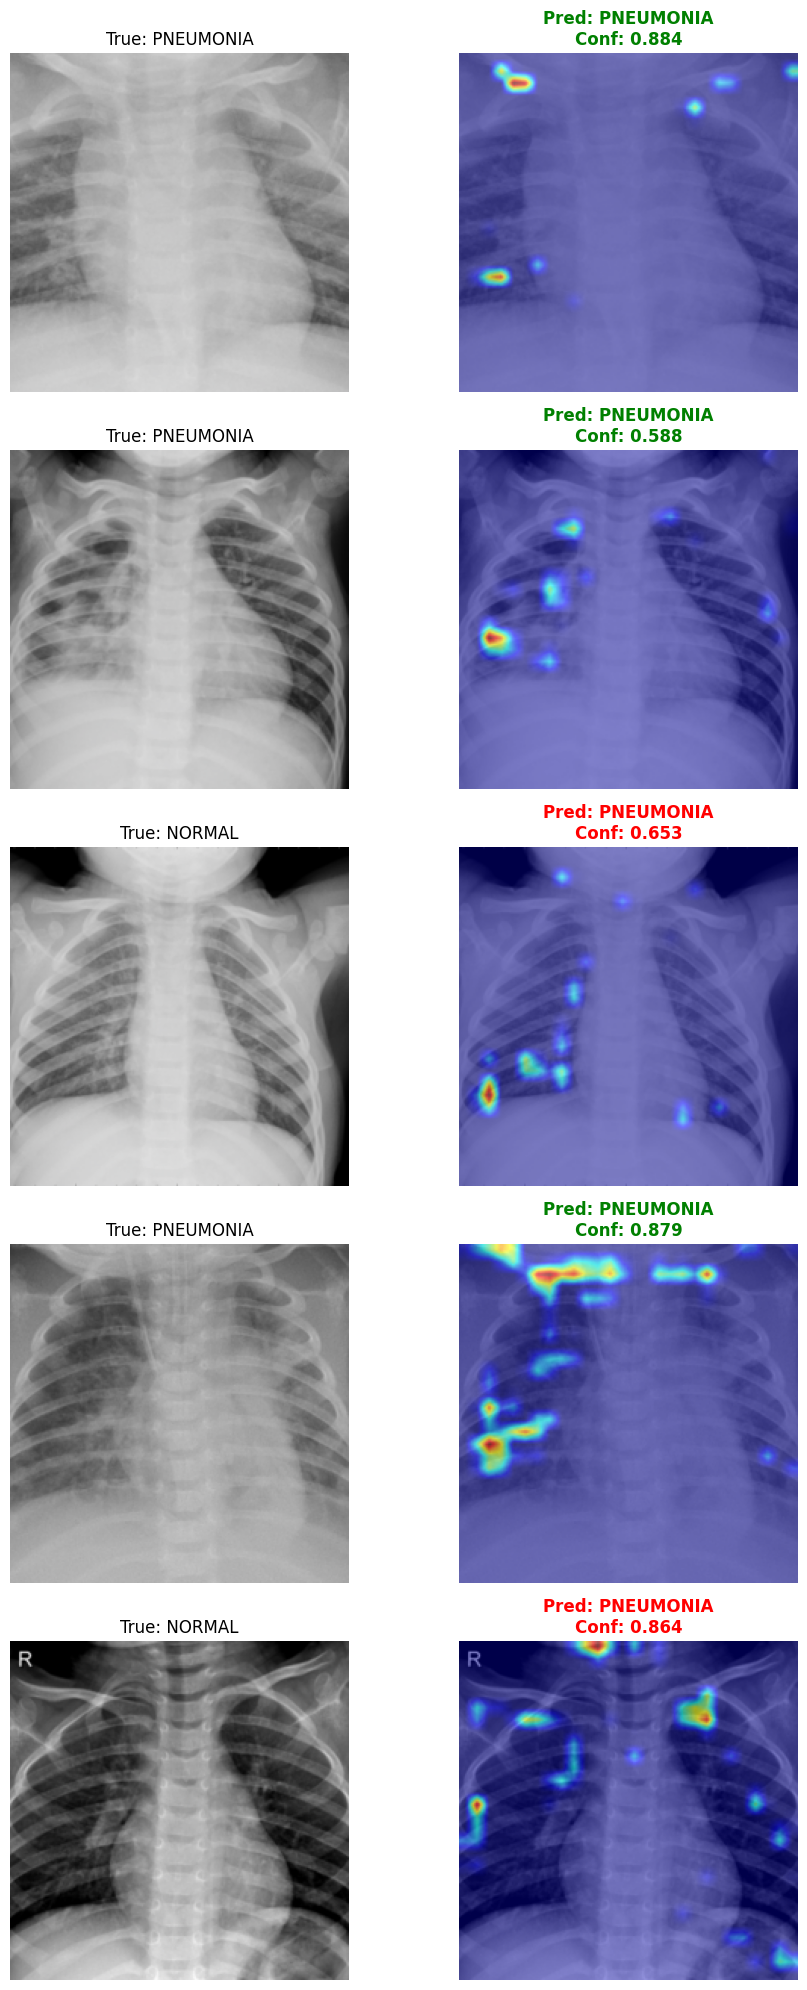

In [ ]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image

# 1. Setup GradCAM
model.eval()
target_layers = [model.layer3.conv2] # Targeting the last conv layer

cam = GradCAM(model=model, target_layers=target_layers)

# 2. Config
mean = np.array([0.485, 0.456, 0.406])
std = np.array([0.229, 0.224, 0.225])
class_names = ['NORMAL', 'PNEUMONIA']
num_images = 5 # Reduced to 5 for quicker plotting

fig, axes = plt.subplots(num_images, 2, figsize=(10, num_images * 4))

for i in range(num_images):
    idx = np.random.randint(len(val_data))
    image, label = val_data[idx]
    input_tensor = image.unsqueeze(0).to(device)

    # Generate CAM
    grayscale_cam = cam(input_tensor=input_tensor)[0]

    # Post-process image for display
    rgb_img = image.permute(1, 2, 0).cpu().numpy()
    rgb_img = std * rgb_img + mean
    rgb_img = np.clip(rgb_img, 0, 1)

    visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

    # Get prediction
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)
        pred = torch.argmax(outputs, dim=1).item()
        confidence = probs[0][pred].item()

    # Plotting
    axes[i, 0].imshow(rgb_img)
    axes[i, 0].set_title(f"True: {class_names[label]}")
    axes[i, 0].axis("off")

    axes[i, 1].imshow(visualization)
    color = 'green' if label == pred else 'red'
    axes[i, 1].set_title(f"Pred: {class_names[pred]}\nConf: {confidence:.3f}", color=color, fontweight='bold')
    axes[i, 1].axis("off")

plt.tight_layout()
plt.show()

## loading from scratch

In [ ]:
loaded_model = torch.load(
    "XRay_model-v1.pt",

    weights_only=False, # Changed to False to allow loading custom classes
)
print("Model loaded successfully!")

Model loaded successfully!


In [ ]:
loaded_model

RobustXrayNet(
  (conv_in): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
  )
  (layer1): ResBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (shortcut): Sequential(
      (0): Conv2d(32, 64, kernel_size=(1, 1), stride=(2, 2), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
  )
  (layer2): ResBlock(
    (conv1): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_run

### predict the Pneumonia

In [ ]:
def predictPneumonia(device, model, img_path):

    test_transform = transforms.Compose([
    transforms.Resize(224),                # Resizes image to 224 pixels
    transforms.CenterCrop(224),            # Crops center to 224x224
    transforms.ToTensor(),                 # Converts to Tensor (pixel values [0.0, 1.0])
    transforms.Normalize([0.485, 0.456, 0.406], # Applies same ImageNet normalization as training
                          [0.229, 0.224, 0.225])
      ])

    # 1. Load and Transform the Image
    img = Image.open(img_path).convert('RGB')
    img_tensor = test_transform(img) # Uses the same transform as your test set
    img_tensor = img_tensor.unsqueeze(0).to(device) # Add batch dimension

    # 2. Get Prediction
    model.eval()
    with torch.no_grad():
        output = model(img_tensor)
        # FIX: Apply Softmax to convert raw logits to probabilities
        probs = F.softmax(output, dim=1).cpu().numpy()[0]

    # 3. Visualization
    class_names = ['NORMAL', 'PNEUMONIA']
    pred_idx = np.argmax(probs)

    # Plotting
    fig, (ax1, ax2) = plt.subplots(figsize=(8, 4), ncols=2)

    # Show Image
    ax1.imshow(img)
    ax1.set_title(f"Prediction: {class_names[pred_idx]}")
    ax1.axis('off')

    # Show Confidence Graph
    ax2.barh(class_names, probs, color=['blue', 'red'])
    ax2.set_title('Confidence Levels')
    ax2.set_xlim(0, 1)
    plt.tight_layout()
    plt.show()

    return class_names[pred_idx], probs[pred_idx]

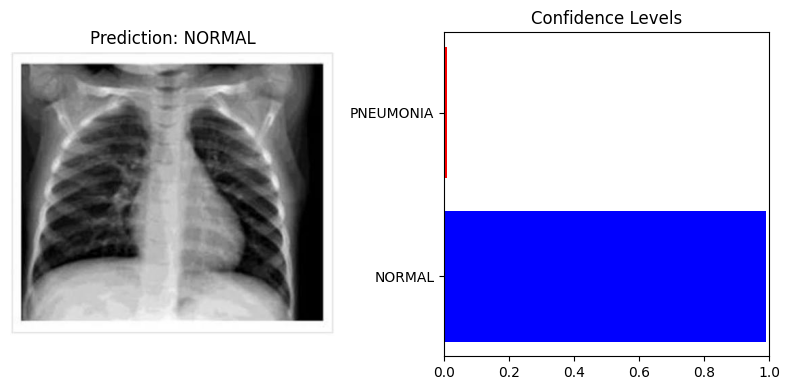

('NORMAL', np.float32(0.99199194))

In [ ]:

predictPneumonia(device, loaded_model, "/content/N1.jpeg")

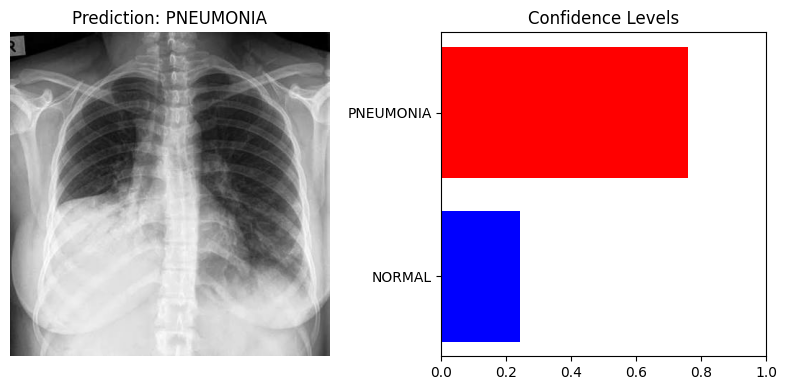

('PNEUMONIA', np.float32(0.7581192))

In [ ]:
predictPneumonia(device, loaded_model, "/content/PN1.jpeg")

In [ ]:
curr_dir = '/content'

NORMAL


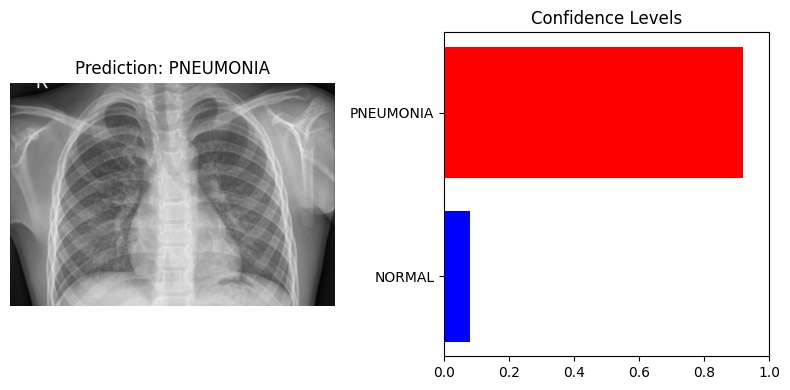

('PNEUMONIA', np.float32(0.9210848))
NORMAL


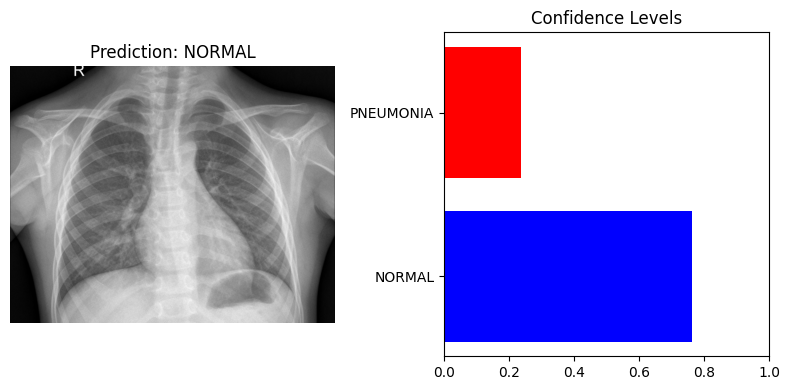

('NORMAL', np.float32(0.7628527))
PNEUMONIA


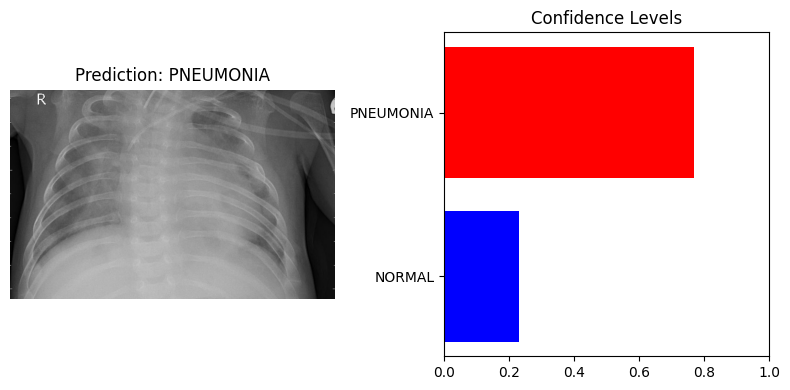

('PNEUMONIA', np.float32(0.76837695))
PNEUMONIA


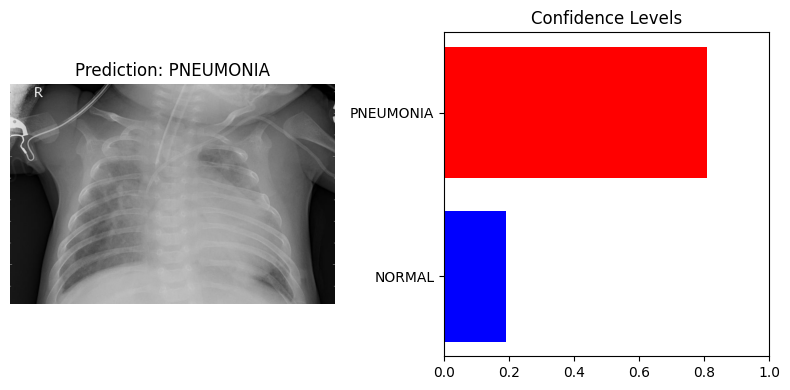

('PNEUMONIA', np.float32(0.81020176))
NORMAL


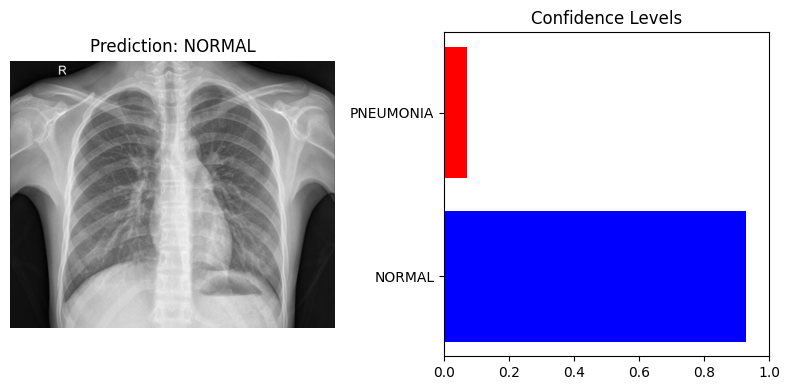

('NORMAL', np.float32(0.930521))
PNEUMONIA


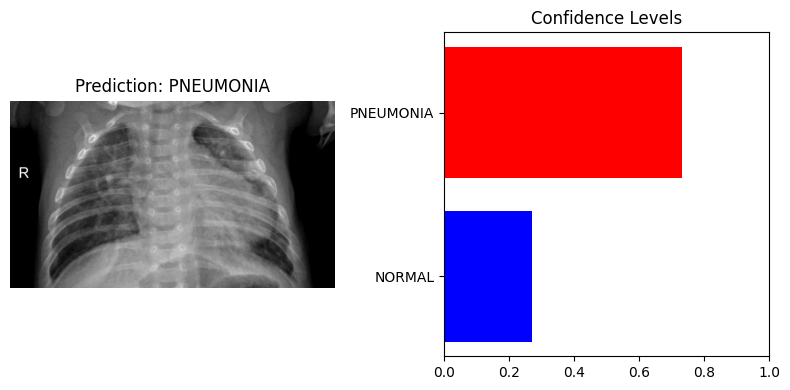

('PNEUMONIA', np.float32(0.7308676))
PNEUMONIA


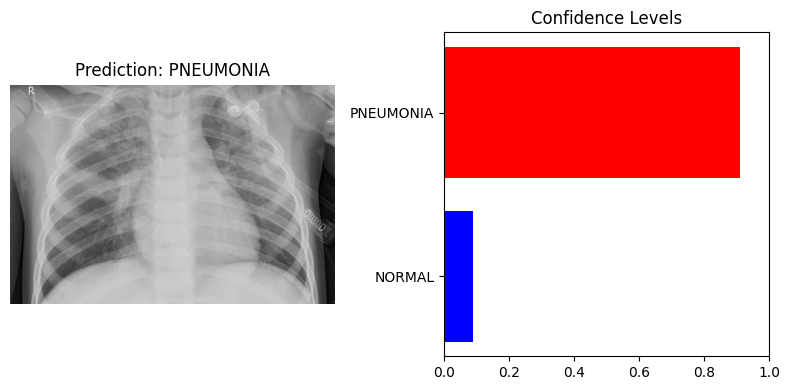

('PNEUMONIA', np.float32(0.90990883))
NORMAL


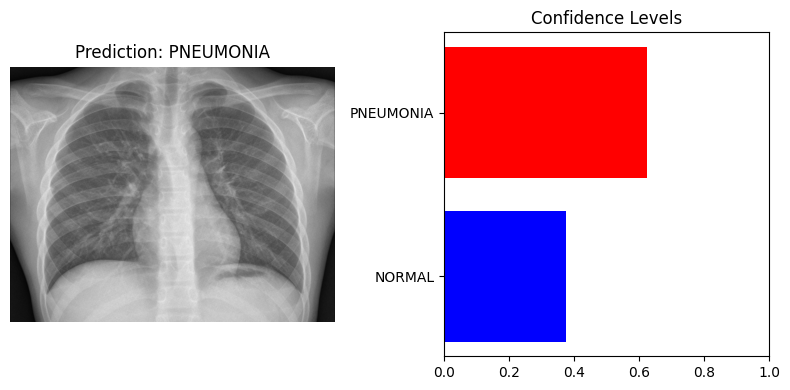

('PNEUMONIA', np.float32(0.62466913))
NORMAL


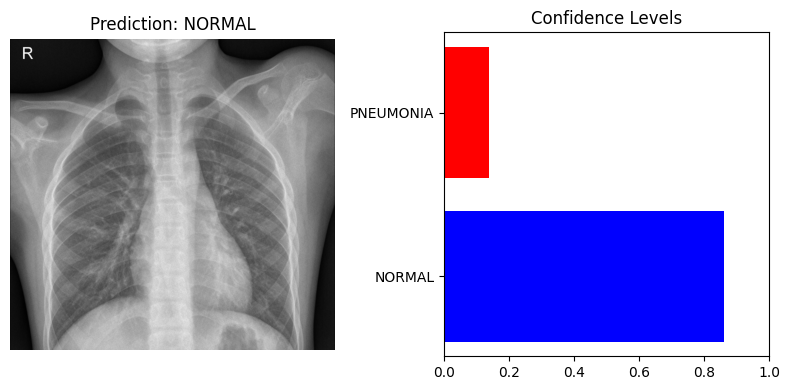

('NORMAL', np.float32(0.8619807))


In [ ]:
for file in os.listdir(curr_dir):
  if file.endswith(('.jpeg','.jpg','.png')):
    print("NORMAL" if 'person' not in file else "PNEUMONIA")
    print(predictPneumonia(device, model, os.path.join(curr_dir, file)))